In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
from sklearn.preprocessing import PowerTransformer

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

# Yeo-Johnson Transformation for Clustering

In [27]:
original_X = X.copy()

In [28]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_std = pt.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [29]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.735252,0.067055,0.176922,0.072022,0.104910,-0.000955,-0.190635,-0.021816,0.103330,-0.274204,...,1.042615,-0.340702,-0.305657,0.622355,-0.784694,-0.404309,-0.370546,-0.074611,-0.654022,-0.325914
1,1.029207,-1.298903,-2.046814,-1.421627,-1.344285,-1.500591,-0.993359,-1.453969,-1.512997,-0.807533,...,1.929439,1.907148,0.939011,-1.489676,-0.784694,1.826912,1.188847,1.689445,1.560347,0.852496
2,0.480839,0.581443,0.777497,0.444135,0.593101,0.323069,0.452558,0.617141,0.651680,0.764603,...,-0.799521,0.082511,0.147926,0.741227,0.236612,-0.110511,-1.026597,-1.065926,-0.824361,-0.125568
3,1.080021,-0.986786,-1.714238,-1.314128,-1.459229,-1.636023,-0.469852,-1.044798,-1.371728,-0.684399,...,1.846691,1.751709,0.986180,-1.383365,-0.784694,0.301039,1.216712,-1.065926,1.122247,1.296177
4,0.946400,-0.689355,-0.765790,-0.468644,-0.828545,-0.393167,-0.250949,-0.482649,-0.997043,0.080384,...,-0.799521,0.230152,0.900131,-1.607406,1.784568,1.860059,1.405024,1.782787,1.919501,1.900963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.200607,-0.027337,-0.469576,-0.601731,-0.503317,-0.423114,-0.843152,-0.642530,-0.522668,-0.587170,...,-0.799521,-0.050750,-0.332827,0.301629,-0.784694,-0.811377,0.115613,-1.065926,-0.733951,-0.371465
135,0.368838,1.721586,0.901503,0.002519,0.280704,0.389333,0.314470,0.253816,0.527224,0.286038,...,-0.000653,0.215135,0.445866,-0.027763,-0.784694,0.654869,-0.266178,0.138716,-0.145951,0.659834
136,0.459982,0.996190,0.306773,-0.316986,-0.665131,-0.117023,0.464099,-0.299082,0.050381,0.019889,...,-0.799521,-1.105445,-1.073694,1.149438,-0.784694,-1.222412,-0.358889,-1.065926,-0.928256,0.305804
137,-0.551976,-0.284014,0.183709,0.314722,0.178739,0.095604,0.005239,0.207510,0.224901,0.081128,...,-0.799521,-0.455330,0.120914,-0.137599,-0.784694,0.225798,0.256551,-0.175482,-0.103535,0.868321


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

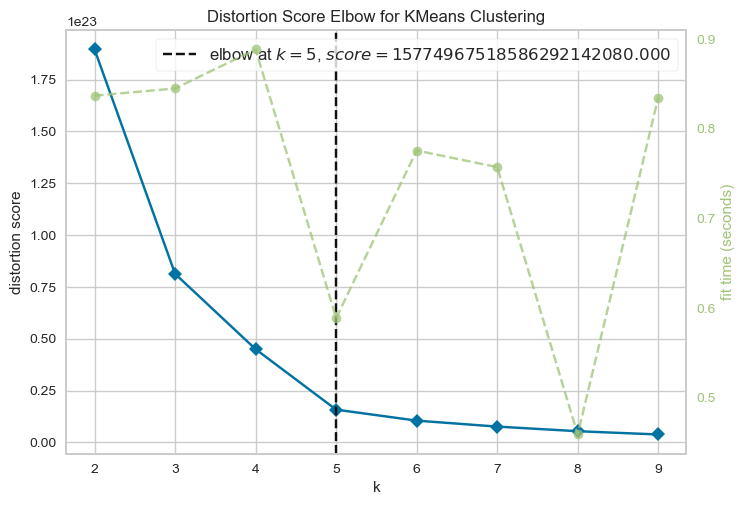

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [30]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [31]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: gldm_DependenceNonUniformity_d_1_CT_c16, Coefficient: -5.082715638881932


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: glcm_DifferenceAverage_d_1_PET_c04, Coefficient: 4.462746305790114


...

Cluster 2: Most important feature: first_order_90Percentile_CT, Coefficient: -58862535422066.14


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 3: Most important feature: glcm_ClusterTendency_d_1_CT_b20, Coefficient: -2.3857676132467227


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 4: Most important feature: glcm_Autocorrelation_d_1_PET_c04, Coefficient: -2.8153197054263517


In [35]:
selected_features

['gldm_DependenceNonUniformity_d_1_CT_c16',
 'glcm_DifferenceAverage_d_1_PET_c04',
 'first_order_90Percentile_CT',
 'glcm_ClusterTendency_d_1_CT_b20',
 'glcm_Autocorrelation_d_1_PET_c04']

In [36]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Yeo-Johnson Transformation

In [37]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [38]:
X_new

,gldm_DependenceNonUniformity_d_1_CT_c16,glcm_DifferenceAverage_d_1_PET_c04,first_order_90Percentile_CT,glcm_ClusterTendency_d_1_CT_b20,glcm_Autocorrelation_d_1_PET_c04
0,795.553102,0.356587,1177.917830,54.573213,18.872870
1,123.426126,0.420129,1109.046098,33.386585,14.225748
2,4018.147125,0.325835,1149.884925,40.784508,18.694309
3,132.029667,0.401664,1126.003305,45.463501,13.303444
4,198.074133,0.510112,1134.384047,52.638118,21.595114
...,...,...,...,...,...
134,364.958418,0.409956,1157.360037,12.108105,15.641841
135,7880.282053,0.321183,1126.367132,28.069410,25.181360
136,2004.754079,0.374487,1111.612526,35.905635,14.917887
137,1231.652900,0.402135,1117.834717,6.483329,24.718087


In [39]:
X_new_std

,gldm_DependenceNonUniformity_d_1_CT_c16,glcm_DifferenceAverage_d_1_PET_c04,first_order_90Percentile_CT,glcm_ClusterTendency_d_1_CT_b20,glcm_Autocorrelation_d_1_PET_c04
0,-0.281322,-0.094031,8.604228e-16,0.451170,0.310334
1,-1.538990,0.595643,-3.885781e-16,-0.004580,-0.722511
2,0.720827,-0.468257,3.885781e-16,0.185710,0.272323
3,-1.491572,0.405940,-5.551115e-17,0.286286,-0.939932
4,-1.209134,1.412495,1.110223e-16,0.418997,0.875895
...,...,...,...,...,...
134,-0.793546,0.492151,5.273559e-16,-1.063704,-0.397407
135,1.113717,-0.527421,-5.551115e-17,-0.174678,1.585932
136,0.300721,0.111075,-3.330669e-16,0.065319,-0.562352
137,-0.002663,0.410886,-2.220446e-16,-1.779936,1.496209


In [40]:
MAASTRO_new

,gldm_DependenceNonUniformity_d_1_CT_c16,glcm_DifferenceAverage_d_1_PET_c04,first_order_90Percentile_CT,glcm_ClusterTendency_d_1_CT_b20,glcm_Autocorrelation_d_1_PET_c04
0,12196.315125,0.335443,1103.940398,15.819587,22.541648
1,4519.652975,0.279434,1117.575395,95.515772,8.953439
2,3625.016252,0.310763,1110.775817,43.157032,14.113279
3,635.235614,0.301684,1191.267456,390.902346,12.130050
4,3431.608089,0.300615,1108.918120,11.504749,17.134919
...,...,...,...,...,...
94,2609.957482,0.327473,1132.303273,69.352879,16.905607
95,2051.596318,0.310449,1108.789902,360.715961,12.618069
96,3489.732357,0.264803,1107.996338,29.424999,12.488575
97,3253.768315,0.305581,1161.546578,43.230094,16.121534


In [41]:
MAASTRO_new_std

,gldm_DependenceNonUniformity_d_1_CT_c16,glcm_DifferenceAverage_d_1_PET_c04,first_order_90Percentile_CT,glcm_ClusterTendency_d_1_CT_b20,glcm_Autocorrelation_d_1_PET_c04
0,1.361299,-0.348239,-5.273559e-16,-0.770048,1.066892
1,0.790419,-1.090997,-2.220446e-16,0.923934,-2.040838
2,0.659558,-0.662484,-3.608225e-16,0.238307,-0.748773
3,-0.427211,-0.783134,1.082467e-15,1.913917,-1.223749
4,0.626799,-0.797524,-3.885781e-16,-1.120871,-0.064908
...,...,...,...,...,...
94,0.461885,-0.447593,8.326673e-17,0.659539,-0.115336
95,0.314918,-0.666615,-4.163336e-16,1.864458,-1.104677
96,0.636844,-1.303381,-4.163336e-16,-0.127959,-1.136126
97,0.594915,-0.731004,6.106227e-16,0.239873,-0.289490


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [42]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 01:26:30,724] A new study created in memory with name: no-name-53e34959-6683-442d-8219-d2f5a5e6d07c


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.645021645021645
Fold 2 C-index: 0.6473214285714286
Fold 3 C-index: 0.7303921568627451


[I 2024-04-16 01:26:32,213] A new study created in memory with name: no-name-ad3c1e7f-d774-4d41-9d80-77042bd20fbb


Fold 4 C-index: 0.6624472573839663
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:26:32,203] Trial 0 finished with value: 0.6572242909951871 and parameters: {}. Best is trial 0 with value: 0.6572242909951871.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6572242909951871], datetime_start=datetime.datetime(2024, 4, 16, 1, 26, 31, 104277), datetime_complete=datetime.datetime(2024, 4, 16, 1, 26, 32, 201384), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6572242909951871


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.18487023005660022
Fold 2 IBS: 0.19861679270207727
Fold 3 IBS: 0.18140758001851662
Fold 4 IBS: 0.19747856974047648
Fold 5 IBS: 0.2438907460194245
[I 2024-04-16 01:26:33,259] Trial 0 finished with value: 0.20125278370741903 and parameters: {}. Best is trial 0 with value: 0.20125278370741903.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20125278370741903], datetime_start=datetime.datetime(2024, 4, 16, 1, 26, 32, 247140), datetime_complete=datetime.datetime(2024, 4, 16, 1, 26, 33, 259552), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20125278370741903


In [43]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [44]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.657
train_ibs:  0.201


#### Test

In [45]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [46]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.589
IBS score: 0.236


In [47]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [48]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:26:36,259] A new study created in memory with name: no-name-8a410e5f-a3fc-4966-b3ed-a2e59f6c220b


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6233766233766234
Fold 2 C-index: 0.4955357142857143
Fold 3 C-index: 0.625


[I 2024-04-16 01:26:36,869] A new study created in memory with name: no-name-ba6bb20d-1bfd-4052-875f-9ba53406848a


Fold 4 C-index: 0.6603375527426161
Fold 5 C-index: 0.5751173708920188
[I 2024-04-16 01:26:36,857] Trial 0 finished with value: 0.5958734522593945 and parameters: {}. Best is trial 0 with value: 0.5958734522593945.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5958734522593945], datetime_start=datetime.datetime(2024, 4, 16, 1, 26, 36, 297102), datetime_complete=datetime.datetime(2024, 4, 16, 1, 26, 36, 857075), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5958734522593945


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2139765165103009
Fold 2 IBS: 0.22157791544411493
Fold 3 IBS: 0.20453594087790397
Fold 4 IBS: 0.2247380328827946
Fold 5 IBS: 0.21812431369601673
[I 2024-04-16 01:26:37,842] Trial 0 finished with value: 0.2165905438822262 and parameters: {}. Best is trial 0 with value: 0.2165905438822262.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905438822262], datetime_start=datetime.datetime(2024, 4, 16, 1, 26, 36, 940837), datetime_complete=datetime.datetime(2024, 4, 16, 1, 26, 37, 841967), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905438822262


In [50]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.596
train_ibs:  0.217


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.566


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:26:38,312] A new study created in memory with name: no-name-1effd737-bb00-4807-82d4-3d0869cd6499


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6651785714285714
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.6962025316455697


[I 2024-04-16 01:26:39,818] A new study created in memory with name: no-name-d8918e0a-9ab9-4948-951d-a354c00ea4f2


Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:26:39,802] Trial 0 finished with value: 0.6703733595984627 and parameters: {}. Best is trial 0 with value: 0.6703733595984627.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6703733595984627], datetime_start=datetime.datetime(2024, 4, 16, 1, 26, 38, 351150), datetime_complete=datetime.datetime(2024, 4, 16, 1, 26, 39, 801824), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6703733595984627


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.1847926641880011
Fold 2 IBS: 0.19828684439935237
Fold 3 IBS: 0.18106583969376966
Fold 4 IBS: 0.18911036842537388
Fold 5 IBS: 0.23398249694488935
[I 2024-04-16 01:26:41,547] Trial 0 finished with value: 0.1974476427302773 and parameters: {}. Best is trial 0 with value: 0.1974476427302773.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.1974476427302773], datetime_start=datetime.datetime(2024, 4, 16, 1, 26, 39, 986216), datetime_complete=datetime.datetime(2024, 4, 16, 1, 26, 41, 546820), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.1974476427302773


In [56]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.67
train_ibs:  0.197


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.591


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.232


In [60]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:26:42,361] A new study created in memory with name: no-name-f62f7932-9314-40c9-bdf4-de2280154ad2


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6651785714285714
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:26:44,046] Trial 0 finished with value: 0.6713537517553254 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6713537517553254.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:26:45,211] Trial 1 finished with value: 0.6722466088981826 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.6722466088981826.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:26:46,556] Trial 2 finished with value: 0.6722466088981826 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6651785714285714
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:27:16,210] Trial 24 finished with value: 0.6703733595984627 and parameters: {'l1_ratio': 0.8723606880092448}. Best is trial 1 with value: 0.6722466088981826.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:27:17,360] Trial 25 finished with value: 0.6722466088981826 and parameters: {'l1_ratio': 0.45903747271503514}. Best is trial 1 with value: 0.6722466088981826.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6651785714285714
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:27:18,877] Trial 26 finished with value: 0.6713537517553254 and parameters: {'l1_ratio': 0.3527001258697712

Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:27:50,633] Trial 47 finished with value: 0.670400415875519 and parameters: {'l1_ratio': 0.08118016122677446}. Best is trial 1 with value: 0.6722466088981826.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:27:52,287] Trial 48 finished with value: 0.6722466088981826 and parameters: {'l1_ratio': 0.26268375459327914}. Best is trial 1 with value: 0.6722466088981826.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6651785714285714
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 01:27:53,949] Trial 49 finished with value: 0.6713537517553254 and parameters: {'l1_ratio': 0.5016408715463114}. Best is trial 1 with value: 0.6722466088981826.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.7

...

Fold 1 IBS: 0.18482791321819558
Fold 2 IBS: 0.19827601215625118
Fold 3 IBS: 0.18099160136328596
Fold 4 IBS: 0.18912946644316472
Fold 5 IBS: 0.23399809031884425
[I 2024-04-16 01:29:00,952] Trial 0 finished with value: 0.19744461669994834 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.19744461669994834.
Fold 1 IBS: 0.1849524972416388
Fold 2 IBS: 0.19830674757675318
Fold 3 IBS: 0.1807905409567461
Fold 4 IBS: 0.1890880874169066
Fold 5 IBS: 0.23397908602190656
[I 2024-04-16 01:29:02,228] Trial 1 finished with value: 0.19742339184279026 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.19742339184279026.
Fold 1 IBS: 0.1849622382367765
Fold 2 IBS: 0.19833026486331246
Fold 3 IBS: 0.18075453452658755
Fold 4 IBS: 0.18905779127281006
Fold 5 IBS: 0.23398912483152182
[I 2024-04-16 01:29:03,825] Trial 2 finished with value: 0.19741879074620167 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.1974187907462

Fold 1 IBS: 0.18492375576231818
Fold 2 IBS: 0.1982887830243262
Fold 3 IBS: 0.18084698110867461
Fold 4 IBS: 0.18911569800332087
Fold 5 IBS: 0.23397783918683773
[I 2024-04-16 01:29:44,410] Trial 25 finished with value: 0.19743061141709553 and parameters: {'l1_ratio': 0.3804525958179419}. Best is trial 22 with value: 0.19739271187825164.
Fold 1 IBS: 0.18493602305703655
Fold 2 IBS: 0.19830014483931363
Fold 3 IBS: 0.18081614632065343
Fold 4 IBS: 0.18908684616847538
Fold 5 IBS: 0.23398056944810153
[I 2024-04-16 01:29:45,916] Trial 26 finished with value: 0.1974239459667161 and parameters: {'l1_ratio': 0.3312072877416866}. Best is trial 22 with value: 0.19739271187825164.
Fold 1 IBS: 0.18504359100168125
Fold 2 IBS: 0.1983163387376715
Fold 3 IBS: 0.1806522425809971
Fold 4 IBS: 0.1890232166700352
Fold 5 IBS: 0.2339764432286881
[I 2024-04-16 01:29:47,623] Trial 27 finished with value: 0.19740236644381462 and parameters: {'l1_ratio': 0.07046652721581821}. Best is trial 22 with value: 0.1973927118

Fold 5 IBS: 0.23397019090372803
[I 2024-04-16 01:30:21,354] Trial 49 finished with value: 0.19740825561842643 and parameters: {'l1_ratio': 0.11861526611797166}. Best is trial 22 with value: 0.19739271187825164.
Fold 1 IBS: 0.1848829286476945
Fold 2 IBS: 0.19829324242208307
Fold 3 IBS: 0.18089038802245205
Fold 4 IBS: 0.18913421464529398
Fold 5 IBS: 0.23399276955035905
[I 2024-04-16 01:30:23,186] Trial 50 finished with value: 0.19743870865757654 and parameters: {'l1_ratio': 0.47241766561900594}. Best is trial 22 with value: 0.19739271187825164.
Fold 1 IBS: 0.1850805520299186
Fold 2 IBS: 0.1983314127051209
Fold 3 IBS: 0.18063997909317187
Fold 4 IBS: 0.18901738984477023
Fold 5 IBS: 0.23394717315715657
[I 2024-04-16 01:30:24,853] Trial 51 finished with value: 0.19740330136602763 and parameters: {'l1_ratio': 0.06554993013475165}. Best is trial 22 with value: 0.19739271187825164.
Fold 1 IBS: 0.21373057846154642
Fold 2 IBS: 0.2215011633582659
Fold 3 IBS: 0.20424468890014177
Fold 4 IBS: 0.22435

Fold 1 IBS: 0.18502139182897148
Fold 2 IBS: 0.19834258736040788
Fold 3 IBS: 0.1806820004306711
Fold 4 IBS: 0.18904384779128908
Fold 5 IBS: 0.23397548954199074
[I 2024-04-16 01:31:09,737] Trial 74 finished with value: 0.19741306339066605 and parameters: {'l1_ratio': 0.12031452221010544}. Best is trial 22 with value: 0.19739271187825164.
Fold 1 IBS: 0.1849621840686837
Fold 2 IBS: 0.19831589725484527
Fold 3 IBS: 0.18076944668830527
Fold 4 IBS: 0.1890869873699251
Fold 5 IBS: 0.2339809795030087
[I 2024-04-16 01:31:12,001] Trial 75 finished with value: 0.1974230989769536 and parameters: {'l1_ratio': 0.2518775663200761}. Best is trial 22 with value: 0.19739271187825164.
Fold 1 IBS: 0.18498859423768602
Fold 2 IBS: 0.19832507586142648
Fold 3 IBS: 0.18072961336011728
Fold 4 IBS: 0.18906485854631902
Fold 5 IBS: 0.23397729774578926
[I 2024-04-16 01:31:13,929] Trial 76 finished with value: 0.1974170879502676 and parameters: {'l1_ratio': 0.19301863619298948}. Best is trial 22 with value: 0.197392711

Fold 5 IBS: 0.23396887446530976
[I 2024-04-16 01:31:55,310] Trial 98 finished with value: 0.19740791128848642 and parameters: {'l1_ratio': 0.09493997302573938}. Best is trial 22 with value: 0.19739271187825164.
Fold 1 IBS: 0.21309633035738734
Fold 2 IBS: 0.2213227655207557
Fold 3 IBS: 0.20349141238595642
Fold 4 IBS: 0.22334048977754253
Fold 5 IBS: 0.23394196290307379
[I 2024-04-16 01:31:57,111] Trial 99 finished with value: 0.21903859218894314 and parameters: {'l1_ratio': 0.017947856638680336}. Best is trial 22 with value: 0.19739271187825164.


* Best trial for IBS: 
 FrozenTrial(number=22, state=TrialState.COMPLETE, values=[0.19739271187825164], datetime_start=datetime.datetime(2024, 4, 16, 1, 29, 38, 350560), datetime_complete=datetime.datetime(2024, 4, 16, 1, 29, 40, 466398), params={'l1_ratio': 0.07181511589086235}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=22, value=N

In [62]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.672
train_ibs:  0.197


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.28621072101688444)

test_cindex : 0.591


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.07181511589086235)

test_ibs:  0.232


In [66]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 01:31:58,117] A new study created in memory with name: no-name-b6e540e2-719e-4609-a986-84db4b11fa1f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7142857142857143
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.6813725490196079
Fold 4 C-index: 0.6983122362869199
Fold 5 C-index: 0.596244131455399
[I 2024-04-16 01:32:21,019] Trial 0 finished with value: 0.6621500690666711 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6621500690666711.
Fold 1 C-index: 0.70995670995671
Fold 2 C-index: 0.6294642857142857
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.7088607594936709
Fold 5 C-index: 0.6244131455399061
[I 2024-04-16 01:32:38,040] Trial 1 finished with value: 0.6825781958271891 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'ma

Fold 5 C-index: 0.647887323943662
[I 2024-04-16 01:35:12,740] Trial 15 finished with value: 0.7362603047831882 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 10, 'max_depth': 1, 'n_estimators': 383, 'oob_score': True, 'max_samples': 0.7714793888337508, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.18861008087241576, 'warm_start': True}. Best is trial 14 with value: 0.738918638412755.
Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.8705357142857143
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.7215189873417721
Fold 5 C-index: 0.6431924882629108
[I 2024-04-16 01:35:25,224] Trial 16 finished with value: 0.7371945869467578 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 498, 'oob_score': True, 'max_samples': 0.8353789630965257, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.2007870036778815, 'warm_start': True}. Best is trial 14 with value: 0.738918638412755

Fold 1 C-index: 0.70995670995671
Fold 2 C-index: 0.8705357142857143
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index: 0.7679324894514767
Fold 5 C-index: 0.7511737089201878
[I 2024-04-16 01:37:55,657] Trial 30 finished with value: 0.7777628617777197 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 4, 'min_samples_leaf': 11, 'max_depth': 5, 'n_estimators': 242, 'oob_score': True, 'max_samples': 0.9408522113761149, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1291674745594668, 'warm_start': True}. Best is trial 30 with value: 0.7777628617777197.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8660714285714286
Fold 3 C-index: 0.7941176470588235
Fold 4 C-index: 0.7721518987341772
Fold 5 C-index: 0.755868544600939
[I 2024-04-16 01:38:05,215] Trial 31 finished with value: 0.7813648475160174 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 4, 'min_samples_leaf': 11, 'max_depth': 6, 'n_estimators': 242, 'oob_score': True, 'max_samples': 0.9431875751685282, 'ma

...

Fold 1 IBS: 0.17377863882088457
Fold 2 IBS: 0.2024674258934758
Fold 3 IBS: 0.1758997840970239
Fold 4 IBS: 0.18982261792284943
Fold 5 IBS: 0.22326318874505902
[I 2024-04-16 01:49:37,383] Trial 32 finished with value: 0.19304633109585853 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 5, 'n_estimators': 417, 'oob_score': False, 'max_samples': 0.6881300471320988, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.09696255694048989}. Best is trial 5 with value: 0.19160769136239633.
Fold 1 IBS: 0.17287774849837323
Fold 2 IBS: 0.20381948830369503
Fold 3 IBS: 0.17450105274197994
Fold 4 IBS: 0.1919241535420485
Fold 5 IBS: 0.22364059750453325
[I 2024-04-16 01:49:47,621] Trial 33 finished with value: 0.193352608118126 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 4, 'n_estimators': 373, 'oob_score': False, 'max_samples': 0.798454550585337, 'max_features': 'log2', 'min_weight_fraction_le

Fold 1 IBS: 0.17179692430961763
Fold 2 IBS: 0.20304878716147742
Fold 3 IBS: 0.17127960522906657
Fold 4 IBS: 0.18758541850909374
Fold 5 IBS: 0.22191659288090587
[I 2024-04-16 01:52:09,635] Trial 48 finished with value: 0.19112546561803226 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 7, 'min_samples_leaf': 8, 'max_depth': 16, 'n_estimators': 299, 'oob_score': True, 'max_samples': 0.5893093570644944, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.014008011193220066}. Best is trial 39 with value: 0.1910475815745764.
Fold 1 IBS: 0.17220477072914905
Fold 2 IBS: 0.20281054191196368
Fold 3 IBS: 0.17135444319917212
Fold 4 IBS: 0.18766385329780202
Fold 5 IBS: 0.22194644022528218
[I 2024-04-16 01:52:20,974] Trial 49 finished with value: 0.19119600987267382 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 7, 'min_samples_leaf': 8, 'max_depth': 17, 'n_estimators': 310, 'oob_score': True, 'max_samples': 0.5872516163635074, 'max_features': 'auto', 'min_weight_fraction_l

Fold 5 IBS: 0.22607580569090685
[I 2024-04-16 01:54:40,096] Trial 63 finished with value: 0.18958504896400297 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 6, 'min_samples_leaf': 9, 'max_depth': 15, 'n_estimators': 158, 'oob_score': True, 'max_samples': 0.620880056799762, 'max_features': None, 'min_weight_fraction_leaf': 0.0022605798403831224}. Best is trial 63 with value: 0.18958504896400297.
Fold 1 IBS: 0.16792851996376285
Fold 2 IBS: 0.20459536392633768
Fold 3 IBS: 0.17319317087991978
Fold 4 IBS: 0.17706738995547416
Fold 5 IBS: 0.2298766913307006
[I 2024-04-16 01:54:44,808] Trial 64 finished with value: 0.19053222721123902 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 4, 'min_samples_leaf': 9, 'max_depth': 15, 'n_estimators': 133, 'oob_score': True, 'max_samples': 0.6649018727980383, 'max_features': None, 'min_weight_fraction_leaf': 0.0007426492361457065}. Best is trial 63 with value: 0.18958504896400297.
Fold 1 IBS: 0.16834888241598053
Fold 2 IBS: 0.207157

Fold 1 IBS: 0.16843627895205718
Fold 2 IBS: 0.19684052847630454
Fold 3 IBS: 0.17688850988619045
Fold 4 IBS: 0.18850220659784236
Fold 5 IBS: 0.22388232173608058
[I 2024-04-16 01:56:01,842] Trial 79 finished with value: 0.19090996912969502 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 130, 'oob_score': True, 'max_samples': 0.5489444725904093, 'max_features': None, 'min_weight_fraction_leaf': 0.06670852981379592}. Best is trial 63 with value: 0.18958504896400297.
Fold 1 IBS: 0.16709647132362426
Fold 2 IBS: 0.20023704862146666
Fold 3 IBS: 0.1726042267757322
Fold 4 IBS: 0.18041503427818675
Fold 5 IBS: 0.23338567074287297
[I 2024-04-16 01:56:05,592] Trial 80 finished with value: 0.19074769034837655 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 10, 'max_depth': 12, 'n_estimators': 96, 'oob_score': True, 'max_samples': 0.6809942441370432, 'max_features': None, 'min_weight_fraction_leaf'

Fold 1 IBS: 0.17949458386260198
Fold 2 IBS: 0.19840034769036763
Fold 3 IBS: 0.181923071720272
Fold 4 IBS: 0.19252220754023927
Fold 5 IBS: 0.22754745107873228
[I 2024-04-16 01:57:01,569] Trial 95 finished with value: 0.19597753237844265 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 11, 'n_estimators': 104, 'oob_score': True, 'max_samples': 0.7092018070770386, 'max_features': None, 'min_weight_fraction_leaf': 0.2044430572980988}. Best is trial 63 with value: 0.18958504896400297.
Fold 1 IBS: 0.17031228128630874
Fold 2 IBS: 0.20633710163610677
Fold 3 IBS: 0.1794474504371398
Fold 4 IBS: 0.1829811710593465
Fold 5 IBS: 0.22740832233351288
[I 2024-04-16 01:57:02,706] Trial 96 finished with value: 0.19329726535048292 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 32, 'oob_score': True, 'max_samples': 0.6049987011465604, 'max_features': None, 'min_weight_fraction_leaf': 0

In [68]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.885
train_ibs:  0.19


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=19, max_features=None, max_leaf_nodes=18,
                     max_samples=0.9096428191819906, min_samples_leaf=2,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.010384276498891197,
                     n_estimators=79, random_state=123, warm_start=True)

test_cindex:  0.614


RandomSurvivalForest(max_depth=15, max_features=None, max_leaf_nodes=6,
                     max_samples=0.620880056799762, min_samples_leaf=9,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.0022605798403831224,
                     n_estimators=158, oob_score=True, random_state=123)

test_ibs:  0.217


In [72]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [73]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 01:57:16,809] A new study created in memory with name: no-name-ab40ca12-20f1-4b8f-b20d-71b2196e0185


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.8382352941176471
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.6854460093896714
[I 2024-04-16 01:57:20,530] Trial 0 finished with value: 0.7558942008625685 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7558942008625685.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:57:25,993] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 4 C-index: 0.7130801687763713
Fold 5 C-index: 0.6150234741784038
[I 2024-04-16 01:58:22,991] Trial 15 finished with value: 0.7183868350335321 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 0 with value: 0.7558942008625685.
Fold 1 C-index: 0.5714285714285714
Fold 2 C-index: 0.6495535714285714
Fold 3 C-index: 0.7377450980392157
Fold 4 C-index: 0.6687763713080169
Fold 5 C-index: 0.539906103286385
[I 2024-04-16 01:58:25,579] Trial 16 finished with value: 0.6334819430981521 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is 

Fold 1 C-index: 0.683982683982684
Fold 2 C-index: 0.7991071428571429
Fold 3 C-index: 0.7941176470588235
Fold 4 C-index: 0.7341772151898734
Fold 5 C-index: 0.6291079812206573
[I 2024-04-16 01:59:02,108] Trial 30 finished with value: 0.7280985340618361 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 11, 'n_estimators': 446, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.4344347067743851, 'min_weight_fraction_leaf': 0.05151632721895192}. Best is trial 23 with value: 0.7560934170423383.
Fold 1 C-index: 0.6926406926406926
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.6619718309859155
[I 2024-04-16 01:59:04,166] Trial 31 finished with value: 0.7387523898439261 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 2, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 409, 'oob_score': False, 'warm_start': True, 'max_feature

...

Fold 1 IBS: 0.20275715399246066
Fold 2 IBS: 0.21421597450627497
Fold 3 IBS: 0.1969782091398356
Fold 4 IBS: 0.21515717561105593
Fold 5 IBS: 0.2160677381864251
[I 2024-04-16 02:06:15,051] Trial 30 finished with value: 0.20903525028721046 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 11, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7262614295600427, 'min_weight_fraction_leaf': 0.04228849156393042}. Best is trial 23 with value: 0.20246072562656234.
Fold 1 IBS: 0.19746701440888856
Fold 2 IBS: 0.2108080640058332
Fold 3 IBS: 0.1904737368234818
Fold 4 IBS: 0.21067626308349766
Fold 5 IBS: 0.21526985201104126
[I 2024-04-16 02:06:22,852] Trial 31 finished with value: 0.20493898606654848 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 5, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 401, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.62

Fold 1 IBS: 0.18415944054360972
Fold 2 IBS: 0.20390661027209547
Fold 3 IBS: 0.17987986258739475
Fold 4 IBS: 0.2009086399669632
Fold 5 IBS: 0.21320194156465852
[I 2024-04-16 02:07:47,477] Trial 45 finished with value: 0.19641129898694434 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 150, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.772972621463588, 'min_weight_fraction_leaf': 0.07325137775339233}. Best is trial 34 with value: 0.19212692821155095.
Fold 1 IBS: 0.204587034293053
Fold 2 IBS: 0.21558956069097135
Fold 3 IBS: 0.19772324570749514
Fold 4 IBS: 0.21677402790074896
Fold 5 IBS: 0.21730198834444034
[I 2024-04-16 02:07:49,837] Trial 46 finished with value: 0.21039517138734176 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 93, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.766481

Fold 1 IBS: 0.17477425937156338
Fold 2 IBS: 0.20012997717053554
Fold 3 IBS: 0.1689422697432348
Fold 4 IBS: 0.19192958555052186
Fold 5 IBS: 0.20914565991815037
[I 2024-04-16 02:08:22,879] Trial 60 finished with value: 0.1889843503508012 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 12, 'n_estimators': 37, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9700885280119657, 'min_weight_fraction_leaf': 0.050706919712783724}. Best is trial 59 with value: 0.18883857923203634.
Fold 1 IBS: 0.17192868009227552
Fold 2 IBS: 0.196676084806922
Fold 3 IBS: 0.17052344506482386
Fold 4 IBS: 0.19220482834145158
Fold 5 IBS: 0.20862485607242232
[I 2024-04-16 02:08:24,237] Trial 61 finished with value: 0.18799157887557905 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 13, 'n_estimators': 36, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.96059

Fold 1 IBS: 0.20137589321548774
Fold 2 IBS: 0.20830070065750192
Fold 3 IBS: 0.194011616541757
Fold 4 IBS: 0.21260094017603173
Fold 5 IBS: 0.21592895524104433
[I 2024-04-16 02:08:49,379] Trial 75 finished with value: 0.20644362116636455 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 13, 'n_estimators': 92, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8805619964696522, 'min_weight_fraction_leaf': 0.09218645434179014}. Best is trial 61 with value: 0.18799157887557905.
Fold 1 IBS: 0.17782779152464406
Fold 2 IBS: 0.20237947104608808
Fold 3 IBS: 0.17516216045257646
Fold 4 IBS: 0.1929166624338505
Fold 5 IBS: 0.21156938297207628
[I 2024-04-16 02:08:50,597] Trial 76 finished with value: 0.19197109368584708 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 35, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.806

Fold 1 IBS: 0.18419545723707006
Fold 2 IBS: 0.2073531354081358
Fold 3 IBS: 0.18044769280399575
Fold 4 IBS: 0.20035464743899262
Fold 5 IBS: 0.21034734115593995
[I 2024-04-16 02:09:14,608] Trial 90 finished with value: 0.19653965480882682 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 17, 'min_samples_leaf': 3, 'max_depth': 14, 'n_estimators': 62, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8883963259386108, 'min_weight_fraction_leaf': 0.004211335094341018}. Best is trial 61 with value: 0.18799157887557905.
Fold 1 IBS: 0.18403859041036874
Fold 2 IBS: 0.2053580251256722
Fold 3 IBS: 0.17054479461782224
Fold 4 IBS: 0.18754677547091678
Fold 5 IBS: 0.21263792793937836
[I 2024-04-16 02:09:17,964] Trial 91 finished with value: 0.19202522271283168 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 13, 'n_estimators': 117, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0

In [74]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.802
train_ibs:  0.188


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=19, max_features=None, max_leaf_nodes=11,
                   max_samples=0.3156467731041482, min_samples_leaf=1,
                   min_weight_fraction_leaf=0.000272750956431346,
                   n_estimators=478, random_state=123, warm_start=True)

C-index score: 0.596


ExtraSurvivalTrees(max_depth=13, max_features=None, max_leaf_nodes=18,
                   max_samples=0.9605973434779875, min_samples_split=2,
                   min_weight_fraction_leaf=0.04815083369212485,
                   n_estimators=36, oob_score=True, random_state=123)

IBS: 0.212


In [78]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [79]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 02:09:41,442] A new study created in memory with name: no-name-354c96d0-f21e-4201-b631-da4ca5dbf4de


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:10:17,826] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:10:38,746] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:20:50,037] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6146704113702727.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:22:06,130] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-16 02:35:15,383] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.6146704113702727.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 02:36:46,802] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.35092096562

...

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-16 03:41:38,209] Trial 44 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.24849699972703826, 'learning_rate': 0.08739840427890608, 'dropout_rate': 0.9925112981171803, 'n_estimators': 238, 'criterion': 'squared_error', 'ccp_alpha': 1.2571847442990605, 'min_weight_fraction_leaf': 0.13620319457876867, 'max_features': 'auto', 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.5876510269738553, 'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 2}. Best is trial 42 with value: 0.21541315332249367.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 03:41:43,727] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.3318702090173651, 'learning_rate': 0.075867972254

Fold 3 IBS: 0.20373174401435343
Fold 4 IBS: 0.22374497443643665
Fold 5 IBS: 0.2179967781965382
[I 2024-04-16 03:43:39,528] Trial 55 finished with value: 0.2158976014478243 and parameters: {'subsample': 0.3616245208750094, 'learning_rate': 0.06363568243053477, 'dropout_rate': 0.7947730940415833, 'n_estimators': 223, 'criterion': 'squared_error', 'ccp_alpha': 0.037450233502366, 'min_weight_fraction_leaf': 0.1498840019922053, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4884772795559432, 'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 42 with value: 0.21541315332249367.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-16 03:43:47,533] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.063747786876849

Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-16 03:44:37,741] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5793283122960363, 'learning_rate': 0.08127606006796943, 'dropout_rate': 0.8962597979590833, 'n_estimators': 85, 'criterion': 'squared_error', 'ccp_alpha': 0.816249103060293, 'min_weight_fraction_leaf': 0.0990747848064058, 'max_features': 'sqrt', 'min_impurity_decrease': 0.010911921009696771, 'validation_fraction': 0.512605471333921, 'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 10, 'max_depth': 5}. Best is trial 65 with value: 0.21528653860435173.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 03:44:42,249] Trial 67 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.435034477554912, 'learning_rate': 0.0667595383937244

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-16 03:45:46,604] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5357913465602108, 'learning_rate': 0.0688819536532142, 'dropout_rate': 0.6862373753371346, 'n_estimators': 138, 'criterion': 'friedman_mse', 'ccp_alpha': 0.3295085048123035, 'min_weight_fraction_leaf': 0.09391314070620446, 'max_features': None, 'min_impurity_decrease': 0.0012137274295836362, 'validation_fraction': 0.31373726823858106, 'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 7, 'max_depth': 7}. Best is trial 72 with value: 0.21435690804427807.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 03:45:49,215] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.4666635842806658, 'learning_rate': 0.07574965743659788, 'dropout_rate': 0.7638959024

Fold 5 IBS: 0.21812431525609574
[I 2024-04-16 03:46:57,578] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5070937054239855, 'learning_rate': 0.09973607041445856, 'dropout_rate': 0.9567720388343455, 'n_estimators': 134, 'criterion': 'friedman_mse', 'ccp_alpha': 1.9600784886531912, 'min_weight_fraction_leaf': 0.16122733058332964, 'max_features': 0.1, 'min_impurity_decrease': 0.00012035323982044348, 'validation_fraction': 0.38803363853798506, 'min_samples_split': 19, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 5}. Best is trial 72 with value: 0.21435690804427807.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-16 03:46:59,275] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.38730242337646104, 'learning_rate': 0.042896534476020334, 'dropout_rate': 0.9006714701688298, 'n_estimators': 83, 

In [80]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [81]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.682
train_ibs:  0.214


#### Test

In [82]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [83]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.01772246444701126,
                                 dropout_rate=0.9308017143391651,
                                 learning_rate=0.06185668684644146,
                                 max_depth=20, max_features='sqrt',
                                 max_leaf_nodes=16,
                                 min_impurity_decrease=0.008845725081239894,
                                 min_samples_leaf=17, min_samples_split=11,
                                 min_weight_fraction_leaf=0.14858144219209024,
                                 n_estimators=59, random_state=123,
                                 subsample=0.5544263040514134,
                                 validation_fraction=0.4573337116459055)

C-index score: 0.606


GradientBoostingSurvivalAnalysis(ccp_alpha=0.00451075339252012,
                                 dropout_rate=0.6764690677768611,
                                 learning_rate=0.08344599141382263, max_depth=4,
                                 max_leaf_nodes=17,
                                 min_impurity_decrease=3.82758474559364e-05,
                                 min_samples_leaf=8, min_samples_split=17,
                                 min_weight_fraction_leaf=0.08603438463501364,
                                 n_estimators=193, random_state=123,
                                 subsample=0.4639828867511839,
                                 validation_fraction=0.2739787370330181)

IBS: 0.219


In [84]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [85]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 03:48:06,850] A new study created in memory with name: no-name-052c15bf-d424-4361-8232-b1eb5eae1456


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6233766233766234
Fold 2 C-index: 0.48214285714285715
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.5821596244131455
[I 2024-04-16 03:48:08,121] Trial 0 finished with value: 0.586667119075381 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.586667119075381.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.48214285714285715
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.5868544600938967
[I 2024-04-16 03:48:19,738] Trial 1 finished with value: 0.5867402853457305 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.5867402853457305.
Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.48660714285714285
Fold 3 C-index: 0.6029411764705882
Fold

Fold 1 C-index: 0.6363636363636364
Fold 2 C-index: 0.5044642857142857
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.5821596244131455
[I 2024-04-16 03:49:51,596] Trial 19 finished with value: 0.6029866877544061 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 12 with value: 0.614914501392706.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.48660714285714285
Fold 3 C-index: 0.6274509803921569
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 03:50:01,314] Trial 20 finished with value: 0.5919255795723368 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 12 with value: 0.614914501392706.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.5178571428571429
Fold 3 C-index: 0.6421568627450981
F

Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.5446428571428571
Fold 3 C-index: 0.6323529411764706
Fold 4 C-index: 0.6540084388185654
Fold 5 C-index: 0.5633802816901409
[I 2024-04-16 03:51:13,749] Trial 38 finished with value: 0.6044180293067324 and parameters: {'subsample': 0.1504722419513361, 'dropout_rate': 0.298015890329657, 'n_estimators': 75, 'learning_rate': 0.07288612365177065}. Best is trial 34 with value: 0.6461379527418352.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.48660714285714285
Fold 3 C-index: 0.6127450980392157
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.5633802816901409
[I 2024-04-16 03:51:15,760] Trial 39 finished with value: 0.584669908539438 and parameters: {'subsample': 0.6100491404460081, 'dropout_rate': 0.5267513165392328, 'n_estimators': 159, 'learning_rate': 0.08712965573449821}. Best is trial 34 with value: 0.6461379527418352.
Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.5178571428571429
Fold 3 C-index: 0.6470588235294118
Fol

...

Fold 2 IBS: 0.2127778974011906
Fold 3 IBS: 0.1917037551400913
Fold 4 IBS: 0.20576449869916183
Fold 5 IBS: 0.21810436877814993
[I 2024-04-16 04:00:01,972] Trial 19 finished with value: 0.20573524642372779 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9930703343219778, 'n_estimators': 51, 'learning_rate': 0.04096883532946153}. Best is trial 19 with value: 0.20573524642372779.
Fold 1 IBS: 0.20408512518413321
Fold 2 IBS: 0.21138955918669516
Fold 3 IBS: 0.19164777729821192
Fold 4 IBS: 0.20725888478812582
Fold 5 IBS: 0.2183419072575236
[I 2024-04-16 04:00:02,570] Trial 20 finished with value: 0.20654465074293796 and parameters: {'subsample': 0.1435040576337751, 'dropout_rate': 0.7933084651006226, 'n_estimators': 43, 'learning_rate': 0.04127909023805986}. Best is trial 19 with value: 0.20573524642372779.
Fold 1 IBS: 0.20423632188730578
Fold 2 IBS: 0.2155315690503933
Fold 3 IBS: 0.1951456736985539
Fold 4 IBS: 0.21146853542692523
Fold 5 IBS: 0.21840444432256936
[I 2024-04

Fold 2 IBS: 0.22986552605446464
Fold 3 IBS: 0.1877155364431702
Fold 4 IBS: 0.2006352830987513
Fold 5 IBS: 0.22480648744367843
[I 2024-04-16 04:00:30,369] Trial 38 finished with value: 0.20859434169504149 and parameters: {'subsample': 0.2411287894440941, 'dropout_rate': 0.13272164755980653, 'n_estimators': 186, 'learning_rate': 0.020939032024934523}. Best is trial 34 with value: 0.20461043840567023.
Fold 1 IBS: 0.20320785625838894
Fold 2 IBS: 0.22857586705284444
Fold 3 IBS: 0.18952819748831867
Fold 4 IBS: 0.20502481406562556
Fold 5 IBS: 0.21941543510836947
[I 2024-04-16 04:00:33,646] Trial 39 finished with value: 0.2091504339947094 and parameters: {'subsample': 0.4405097738755078, 'dropout_rate': 0.9459985101629299, 'n_estimators': 260, 'learning_rate': 0.009381539756297533}. Best is trial 34 with value: 0.20461043840567023.
Fold 1 IBS: 0.20387498827566694
Fold 2 IBS: 0.23377242037948096
Fold 3 IBS: 0.18889977485110646
Fold 4 IBS: 0.205558050063084
Fold 5 IBS: 0.22193796929063253
[I 202

Fold 2 IBS: 0.30091539737727274
Fold 3 IBS: 0.22627183290511024
Fold 4 IBS: 0.2111254297577441
Fold 5 IBS: 0.294936047626558
[I 2024-04-16 04:01:22,496] Trial 57 finished with value: 0.2551782146578228 and parameters: {'subsample': 0.2888110376335854, 'dropout_rate': 0.9604523459148813, 'n_estimators': 364, 'learning_rate': 0.04589729821113898}. Best is trial 34 with value: 0.20461043840567023.
Fold 1 IBS: 0.2090621493222191
Fold 2 IBS: 0.2665678584520134
Fold 3 IBS: 0.2001447352434659
Fold 4 IBS: 0.19764363810450256
Fold 5 IBS: 0.2493914048571952
[I 2024-04-16 04:01:25,510] Trial 58 finished with value: 0.22456195719587924 and parameters: {'subsample': 0.1832249656417103, 'dropout_rate': 0.8602239207074489, 'n_estimators': 236, 'learning_rate': 0.03686775950524939}. Best is trial 34 with value: 0.20461043840567023.
Fold 1 IBS: 0.20394700095105484
Fold 2 IBS: 0.21709388748142097
Fold 3 IBS: 0.1946894223898457
Fold 4 IBS: 0.2109943661630643
Fold 5 IBS: 0.21776795135852
[I 2024-04-16 04:

Fold 2 IBS: 0.26422476735721906
Fold 3 IBS: 0.19826706033218713
Fold 4 IBS: 0.1950622752011719
Fold 5 IBS: 0.2508370693862475
[I 2024-04-16 04:02:02,945] Trial 76 finished with value: 0.22314675337658038 and parameters: {'subsample': 0.16166923171041175, 'dropout_rate': 0.8764727356544575, 'n_estimators': 247, 'learning_rate': 0.03487063878337428}. Best is trial 34 with value: 0.20461043840567023.
Fold 1 IBS: 0.20842986800221813
Fold 2 IBS: 0.25484999151495735
Fold 3 IBS: 0.1965961180609493
Fold 4 IBS: 0.2015236809262429
Fold 5 IBS: 0.24477771586570587
[I 2024-04-16 04:02:05,145] Trial 77 finished with value: 0.2212354748740147 and parameters: {'subsample': 0.21610215495671725, 'dropout_rate': 0.9578267741697286, 'n_estimators': 195, 'learning_rate': 0.041201304562728705}. Best is trial 34 with value: 0.20461043840567023.
Fold 1 IBS: 0.1967135625306978
Fold 2 IBS: 0.22364783945693884
Fold 3 IBS: 0.18684366307176595
Fold 4 IBS: 0.20055474460207737
Fold 5 IBS: 0.22467941833164237
[I 2024

Fold 2 IBS: 0.21607390439141416
Fold 3 IBS: 0.18663364878802038
Fold 4 IBS: 0.19743924096477902
Fold 5 IBS: 0.22661439532527347
[I 2024-04-16 04:02:48,075] Trial 95 finished with value: 0.2047118758544252 and parameters: {'subsample': 0.10092578702655952, 'dropout_rate': 0.9361329037778033, 'n_estimators': 163, 'learning_rate': 0.02634272083831132}. Best is trial 34 with value: 0.20461043840567023.
Fold 1 IBS: 0.20020270426019365
Fold 2 IBS: 0.23099297654973494
Fold 3 IBS: 0.1877004190470638
Fold 4 IBS: 0.2017513694770919
Fold 5 IBS: 0.22620923806866763
[I 2024-04-16 04:02:50,107] Trial 96 finished with value: 0.2093713414805504 and parameters: {'subsample': 0.23536751382835208, 'dropout_rate': 0.951400010129881, 'n_estimators': 163, 'learning_rate': 0.025550280411645688}. Best is trial 34 with value: 0.20461043840567023.
Fold 1 IBS: 0.19896831179739116
Fold 2 IBS: 0.23217012782262558
Fold 3 IBS: 0.19027985268572714
Fold 4 IBS: 0.19805371384776135
Fold 5 IBS: 0.23922986990471362
[I 202

In [86]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [87]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.646
train_ibs:  0.205


#### Test

In [88]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [89]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.6453921708883553,
                                              learning_rate=0.07939146514796744,
                                              n_estimators=5, random_state=123,
                                              subsample=0.10337473249680973)

C-index score: 0.558


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.933870136008782,
                                              learning_rate=0.020684756718428673,
                                              n_estimators=146,
                                              random_state=123,
                                              subsample=0.10403622220164194)

IBS: 0.221


In [90]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [91]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.885,1.0
ExtraSurvivalTrees,0.802,2.0
GradientBoosting,0.682,3.0
CoxElastic,0.672,4.0
CoxLasso,0.670,5.0
CoxPH,0.657,6.0
ComponentwiseGradientBoosting,0.646,7.0
CoxRidge,0.596,8.0


In [92]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.188,1.0
Randomsurvivalforest,0.190,2.0
CoxLasso,0.197,3.5
CoxElastic,0.197,3.5
CoxPH,0.201,5.0
ComponentwiseGradientBoosting,0.205,6.0
GradientBoosting,0.214,7.0
CoxRidge,0.217,8.0


In [93]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
Randomsurvivalforest,0.614,1.0
GradientBoosting,0.606,2.0
ExtraSurvivalTrees,0.596,3.0
CoxLasso,0.591,4.5
CoxElastic,0.591,4.5
CoxPH,0.589,6.0
CoxRidge,0.566,7.0
ComponentwiseGradientBoosting,0.558,8.0


In [94]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.212,1.0
Randomsurvivalforest,0.217,2.0
GradientBoosting,0.219,3.0
CoxRidge,0.221,4.5
ComponentwiseGradientBoosting,0.221,4.5
CoxLasso,0.232,6.5
CoxElastic,0.232,6.5
CoxPH,0.236,8.0


In [95]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/os/yeojohnson/fs_fi/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_os_yeojohnson_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [96]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-16
